In [1]:
HYPERPARAM_ITERS = 1  # Number of iterations for hyperparameter tuning; TODO: increase this for better results, but it will take longer to run.
EXPORT = False  # Whether to export the trained models; set to True to save the models to disk.

# Data Preprocessing

While we did a lot of data cleaning and preprocessing in other notebooks (see notebooks in [data directory](./data)), we will load the data here and do some additional preprocessing to prepare it for model training. This includes combining flight and weather data, adding some historical and derived columns, as well as encoding categorical variables and splitting the data into training and testing sets.

In [18]:
import polars as pl

# Load the data
df = pl.read_parquet("data/flights/Full_Flight_Data.parquet")
df = df.sort("FL_DATE")
df.shape, df.head(), df.tail()

((480802, 60),
 shape: (5, 60)
 ┌─────────────┬─────────────┬────────────┬────────────┬───┬───────┬────────────┬────────────┬──────┐
 │ FL_DATE     ┆ MKT_UNIQUE_ ┆ MKT_CARRIE ┆ OP_UNIQUE_ ┆ … ┆ SPEED ┆ TC-DATA-SH ┆ TC-DATA-HO ┆      │
 │ ---         ┆ CARRIER     ┆ R_FL_NUM   ┆ CARRIER    ┆   ┆ ---   ┆ EET        ┆ LDER       ┆ ---  │
 │ datetime[μs ┆ ---         ┆ ---        ┆ ---        ┆   ┆ str   ┆ ---        ┆ ---        ┆ str  │
 │ ]           ┆ str         ┆ i64        ┆ str        ┆   ┆       ┆ str        ┆ str        ┆      │
 ╞═════════════╪═════════════╪════════════╪════════════╪═══╪═══════╪════════════╪════════════╪══════╡
 │ 2024-01-01  ┆ AA          ┆ 1064       ┆ AA         ┆ … ┆ 0000  ┆ A28NM      ┆ AIRBUS SAS ┆ null │
 │ 00:00:00    ┆             ┆            ┆            ┆   ┆       ┆            ┆ …          ┆      │
 │ 2024-01-01  ┆ AA          ┆ 1153       ┆ AA         ┆ … ┆ 0000  ┆            ┆ …          ┆ null │
 │ 00:00:00    ┆             ┆            ┆        

In [20]:
# Bring in weather data
weather_df = pl.read_parquet("data/weather/isd_weather_data.parquet").sort("timestamp")

# Calculate the actual scheduled departure timestamp from the flight date and scheduled departure time. This keeps the weather alignment consistent with weather info that would have been available at the time of the scheduled departure
df = df.with_columns(
    (
        pl.col("FL_DATE")
        + pl.duration(
            hours=(pl.col("CRS_DEP_TIME") // 100).cast(pl.Int64),
            minutes=(pl.col("CRS_DEP_TIME") % 100).cast(pl.Int64),
        )
    ).alias("scheduled_departure_ts")
).sort("scheduled_departure_ts")

# Merge in most recent weather data that would have been known by scheduled departure
df = df.join_asof(
    weather_df,
    left_on="scheduled_departure_ts",
    right_on="timestamp",
    strategy="backward",
    tolerance="3h",
).drop("timestamp")
df.shape, df.tail(), df.get_column("scheduled_departure_ts")

((240391, 73),
 shape: (5, 73)
 ┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
 │ FL_DATE   ┆ MKT_UNIQU ┆ MKT_CARRI ┆ OP_UNIQUE ┆ … ┆ precip-1h ┆ precip-6h ┆ visibilit ┆ ceiling_ │
 │ ---       ┆ E_CARRIER ┆ ER_FL_NUM ┆ _CARRIER  ┆   ┆ _trace    ┆ _trace    ┆ y_m       ┆ height_m │
 │ datetime[ ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
 │ μs]       ┆ str       ┆ i64       ┆ str       ┆   ┆ i32       ┆ i32       ┆ i32       ┆ i32      │
 ╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
 │ 2025-08-2 ┆ AA        ┆ 4346      ┆ YX        ┆ … ┆ null      ┆ null      ┆ null      ┆ null     │
 │ 7         ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
 │ 00:00:00  ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆          │
 │ 2025-08-2 ┆ AA        ┆ 4643      ┆ YX        ┆ 

In [21]:
from holidays import US

# Time-of-day feature column names
TOD_MONTH = "month"
TOD_DOW = "day_of_week"
TOD_DOM = "day_of_month"
TOD_WEEKEND = "is_weekend"
TOD_HOLIDAY = "is_holiday"

# All derived from scheduled_departure_ts (FL_DATE + CRS_DEP_TIME);
df = df.with_columns(
    [
        pl.col("scheduled_departure_ts").dt.weekday().alias(TOD_DOW),  # 0=Mon, 6=Sun
        pl.col("scheduled_departure_ts").dt.month().cast(pl.Int8).alias(TOD_MONTH),
        pl.col("scheduled_departure_ts").dt.day().cast(pl.Int8).alias(TOD_DOM),
        (pl.col("scheduled_departure_ts").dt.weekday() >= 5)
        .cast(pl.Int8)
        .alias(TOD_WEEKEND),
        (
            pl.col("scheduled_departure_ts")
            .dt.date()
            .map_elements(lambda x: x in US())  # ty:ignore[unresolved-attribute]
            .cast(pl.Int8)
        ).alias(TOD_HOLIDAY),
    ]
)
df.select([TOD_DOW, TOD_MONTH, TOD_WEEKEND, TOD_HOLIDAY]).head()

day_of_week,month,is_weekend,is_holiday
i8,i8,i8,i8
1,1,0,1
1,1,0,1
1,1,0,1
1,1,0,1
1,1,0,1


In [6]:
df = df.with_columns(
    pl.col(
        "MODEL"
    ).str.strip_chars()  # Remove leading/trailing whitespace from MODEL column (e.g., "737-800 " -> "737-800"
)
df.head()

FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_GROUP,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,DIV_AIRPORT_LANDINGS,…,MFR MDL CODE,ENG MFR MDL,YEAR MFR,N_NUMBER_CLEAN,MFR_CODE_CLEAN,CODE,MFR,MODEL,TYPE-ACFT,TYPE-ENG,AC-CAT,BUILD-CERT-IND,NO-ENG,NO-SEATS,AC-WEIGHT,SPEED,TC-DATA-SHEET,TC-DATA-HOLDER,,scheduled_departure_ts,temp,dewtemp,pressure,winddirection,windspeed,skycoverage,precipitation-1h,precipitation-6h,precip-1h_trace,precip-6h_trace,visibility_m,ceiling_height_m,day_of_week,month,day_of_month,is_weekend,is_holiday
datetime[μs],str,i64,str,i64,str,i64,i64,i64,str,i64,i64,i64,f64,i64,f64,i64,i64,f64,i64,i64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,i64,…,str,str,i32,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,datetime[μs],f64,f64,f64,f64,f64,str,f64,f64,i32,i32,i32,i32,i8,i8,i8,i8,i8
2024-01-01 00:00:00,"""AA""",153,"""AA""",19805,"""N894NN""",153,11278,30852,"""DCA""",11057,500,456,-4.0,-1,10.0,506,605,6.0,638,611,-27.0,0.0,null,0.0,98.0,75.0,59.0,1.0,331.0,null,null,null,null,null,null,0,…,"""13844CB""","""13804""",2012,"""894NN""","""13844CB""","""13844CB""","""BOEING ""","""737-823""","""5""","""5 ""","""1""","""0""","""02""","""162""","""CLASS 3""","""0000""",""" """,""" …",null,2024-01-01 05:00:00,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1
2024-01-01 00:00:00,"""AA""",555,"""AA""",19805,"""N315RJ""",555,11278,30852,"""DCA""",13303,500,457,-3.0,-1,13.0,510,724,6.0,749,730,-19.0,0.0,null,0.0,169.0,153.0,134.0,1.0,919.0,null,null,null,null,null,null,0,…,"""13844FZ""","""13134""",2018,"""315RJ""","""13844FZ""","""13844FZ""","""BOEING ""","""737-8""","""5""","""5 ""","""1""","""0""","""02""","""175""","""CLASS 3""","""0000""","""A16WE ""","""BOEING …",null,2024-01-01 05:00:00,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1
2024-01-01 00:00:00,"""AA""",2522,"""AA""",19805,"""N651AW""",2522,11278,30852,"""DCA""",15304,600,549,-11.0,-1,12.0,601,759,3.0,831,802,-29.0,0.0,null,0.0,151.0,133.0,118.0,1.0,814.0,null,null,null,null,null,null,0,…,"""3930326""","""""",1998,"""651AW""","""3930326""","""3930326""","""AIRBUS INDUSTRIE ""","""A320-232""","""5""","""5 ""","""1""","""0""","""02""","""200""","""CLASS 3""","""0000""","""A28NM ""","""AIRBUS SAS …",null,2024-01-01 06:00:00,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1
2024-01-01 00:00:00,"""DL""",410,"""DL""",19790,"""N375NC""",410,11278,30852,"""DCA""",10397,600,557,-3.0,-1,10.0,607,735,4.0,804,739,-25.0,0.0,null,0.0,124.0,102.0,88.0,1.0,547.0,null,null,null,null,null,null,0,…,"""3940010""","""13802""",2002,"""375NC""","""3940010""","""3940010""","""AIRBUS ""","""A320-212""","""5""","""5 ""","""1""","""0""","""02""","""182""","""CLASS 3""","""0000""","""A28NM ""","""AIRBUS SAS …",null,2024-01-01 06:00:00,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1
2024-01-01 00:00:00,"""UA""",260,"""UA""",19977,"""N37255""",260,11278,30852,"""DCA""",13930,600,552,-8.0,-1,10.0,602,634,8.0,717,642,-35.0,0.0,null,0.0,137.0,110.0,92.0,1.0,612.0,null,null,null,null,null,null,0,…,"""13844BZ""","""13802""",2000,"""37255""","""13844BZ""","""13844BZ""","""BOEING ""","""737-824""","""5""","""5 ""","""1""","""0""","""02""","""149""","""CLASS 3""","""0000""",""" """,""" …",null,2024-01-01 06:00:00,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1


In [7]:
df = df.with_columns(
    pl.col(pl.Utf8).cast(pl.Categorical),
    pl.col("scheduled_departure_ts").dt.epoch(
        time_unit="s"
    ),  # Convert datetime to epoch seconds
)

# Drop cancelled flights, and then drop any rows with null values
df = df.filter(pl.col("CANCELLED") == 0)
df.head()

FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_GROUP,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,DIV_AIRPORT_LANDINGS,…,MFR MDL CODE,ENG MFR MDL,YEAR MFR,N_NUMBER_CLEAN,MFR_CODE_CLEAN,CODE,MFR,MODEL,TYPE-ACFT,TYPE-ENG,AC-CAT,BUILD-CERT-IND,NO-ENG,NO-SEATS,AC-WEIGHT,SPEED,TC-DATA-SHEET,TC-DATA-HOLDER,,scheduled_departure_ts,temp,dewtemp,pressure,winddirection,windspeed,skycoverage,precipitation-1h,precipitation-6h,precip-1h_trace,precip-6h_trace,visibility_m,ceiling_height_m,day_of_week,month,day_of_month,is_weekend,is_holiday
datetime[μs],cat,i64,cat,i64,cat,i64,i64,i64,cat,i64,i64,i64,f64,i64,f64,i64,i64,f64,i64,i64,f64,f64,cat,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,cat,i64,…,cat,cat,i32,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,i64,f64,f64,f64,f64,f64,cat,f64,f64,i32,i32,i32,i32,i8,i8,i8,i8,i8
2024-01-01 00:00:00,"""AA""",153,"""AA""",19805,"""N894NN""",153,11278,30852,"""DCA""",11057,500,456,-4.0,-1,10.0,506,605,6.0,638,611,-27.0,0.0,null,0.0,98.0,75.0,59.0,1.0,331.0,null,null,null,null,null,null,0,…,"""13844CB""","""13804""",2012,"""894NN""","""13844CB""","""13844CB""","""BOEING ""","""737-823""","""5""","""5 ""","""1""","""0""","""02""","""162""","""CLASS 3""","""0000""",""" """,""" …",null,1704085200,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1
2024-01-01 00:00:00,"""AA""",555,"""AA""",19805,"""N315RJ""",555,11278,30852,"""DCA""",13303,500,457,-3.0,-1,13.0,510,724,6.0,749,730,-19.0,0.0,null,0.0,169.0,153.0,134.0,1.0,919.0,null,null,null,null,null,null,0,…,"""13844FZ""","""13134""",2018,"""315RJ""","""13844FZ""","""13844FZ""","""BOEING ""","""737-8""","""5""","""5 ""","""1""","""0""","""02""","""175""","""CLASS 3""","""0000""","""A16WE ""","""BOEING …",null,1704085200,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1
2024-01-01 00:00:00,"""AA""",2522,"""AA""",19805,"""N651AW""",2522,11278,30852,"""DCA""",15304,600,549,-11.0,-1,12.0,601,759,3.0,831,802,-29.0,0.0,null,0.0,151.0,133.0,118.0,1.0,814.0,null,null,null,null,null,null,0,…,"""3930326""","""""",1998,"""651AW""","""3930326""","""3930326""","""AIRBUS INDUSTRIE ""","""A320-232""","""5""","""5 ""","""1""","""0""","""02""","""200""","""CLASS 3""","""0000""","""A28NM ""","""AIRBUS SAS …",null,1704088800,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1
2024-01-01 00:00:00,"""DL""",410,"""DL""",19790,"""N375NC""",410,11278,30852,"""DCA""",10397,600,557,-3.0,-1,10.0,607,735,4.0,804,739,-25.0,0.0,null,0.0,124.0,102.0,88.0,1.0,547.0,null,null,null,null,null,null,0,…,"""3940010""","""13802""",2002,"""375NC""","""3940010""","""3940010""","""AIRBUS ""","""A320-212""","""5""","""5 ""","""1""","""0""","""02""","""182""","""CLASS 3""","""0000""","""A28NM ""","""AIRBUS SAS …",null,1704088800,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1
2024-01-01 00:00:00,"""UA""",260,"""UA""",19977,"""N37255""",260,11278,30852,"""DCA""",13930,600,552,-8.0,-1,10.0,602,634,8.0,717,642,-35.0,0.0,null,0.0,137.0,110.0,92.0,1.0,612.0,null,null,null,null,null,null,0,…,"""13844BZ""","""13802""",2000,"""37255""","""13844BZ""","""13844BZ""","""BOEING ""","""737-824""","""5""","""5 ""","""1""","""0""","""02""","""149""","""CLASS 3""","""0000""",""" """,""" …",null,1704088800,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1


Route average delay

In [8]:
df = df.sort("scheduled_departure_ts").with_row_index("_idx")

# Route average delay
df = df.with_columns(
    [
        pl.concat_str(
            pl.col("ORIGIN"), pl.lit("→"), pl.col("DEST_AIRPORT_ID").cast(pl.Utf8)
        ).alias("route"),
        pl.col("DEP_DELAY").cast(pl.Float64).alias("_dep_delay"),
        pl.col("CANCELLED").cast(pl.Float64).alias("_cancelled"),
    ]
)

df = df.with_columns(pl.col("_dep_delay").mean().over("route").alias("avg_rte_delay"))

df = df.with_columns(
    pl.col("_cancelled").mean().over("route").alias("avg_rte_cancelled")
).drop(["_dep_delay", "_cancelled"])

df.head()

_idx,FL_DATE,MKT_UNIQUE_CARRIER,MKT_CARRIER_FL_NUM,OP_UNIQUE_CARRIER,OP_CARRIER_AIRLINE_ID,TAIL_NUM,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT_ID,ORIGIN_CITY_MARKET_ID,ORIGIN,DEST_AIRPORT_ID,CRS_DEP_TIME,DEP_TIME,DEP_DELAY,DEP_DELAY_GROUP,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,CRS_ARR_TIME,ARR_TIME,ARR_DELAY,CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,FLIGHTS,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,FIRST_DEP_TIME,…,N_NUMBER_CLEAN,MFR_CODE_CLEAN,CODE,MFR,MODEL,TYPE-ACFT,TYPE-ENG,AC-CAT,BUILD-CERT-IND,NO-ENG,NO-SEATS,AC-WEIGHT,SPEED,TC-DATA-SHEET,TC-DATA-HOLDER,,scheduled_departure_ts,temp,dewtemp,pressure,winddirection,windspeed,skycoverage,precipitation-1h,precipitation-6h,precip-1h_trace,precip-6h_trace,visibility_m,ceiling_height_m,day_of_week,month,day_of_month,is_weekend,is_holiday,route,avg_rte_delay,avg_rte_cancelled
u32,datetime[μs],cat,i64,cat,i64,cat,i64,i64,i64,cat,i64,i64,i64,f64,i64,f64,i64,i64,f64,i64,i64,f64,f64,cat,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,cat,…,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,cat,i64,f64,f64,f64,f64,f64,cat,f64,f64,i32,i32,i32,i32,i8,i8,i8,i8,i8,str,f64,f64
0,2024-01-01 00:00:00,"""AA""",153,"""AA""",19805,"""N894NN""",153,11278,30852,"""DCA""",11057,500,456,-4.0,-1,10.0,506,605,6.0,638,611,-27.0,0.0,null,0.0,98.0,75.0,59.0,1.0,331.0,null,null,null,null,null,null,…,"""894NN""","""13844CB""","""13844CB""","""BOEING ""","""737-823""","""5""","""5 ""","""1""","""0""","""02""","""162""","""CLASS 3""","""0000""",""" """,""" …",null,1704085200,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1,"""DCA→11057""",18.405263,0.0
1,2024-01-01 00:00:00,"""AA""",555,"""AA""",19805,"""N315RJ""",555,11278,30852,"""DCA""",13303,500,457,-3.0,-1,13.0,510,724,6.0,749,730,-19.0,0.0,null,0.0,169.0,153.0,134.0,1.0,919.0,null,null,null,null,null,null,…,"""315RJ""","""13844FZ""","""13844FZ""","""BOEING ""","""737-8""","""5""","""5 ""","""1""","""0""","""02""","""175""","""CLASS 3""","""0000""","""A16WE ""","""BOEING …",null,1704085200,5.6,0.0,1015.7,0.0,0.0,"""2-3_oktas""",0.0,null,0,0,16093,null,1,1,1,0,1,"""DCA→13303""",16.936007,0.0
2,2024-01-01 00:00:00,"""AA""",2522,"""AA""",19805,"""N651AW""",2522,11278,30852,"""DCA""",15304,600,549,-11.0,-1,12.0,601,759,3.0,831,802,-29.0,0.0,null,0.0,151.0,133.0,118.0,1.0,814.0,null,null,null,null,null,null,…,"""651AW""","""3930326""","""3930326""","""AIRBUS INDUSTRIE ""","""A320-232""","""5""","""5 ""","""1""","""0""","""02""","""200""","""CLASS 3""","""0000""","""A28NM ""","""AIRBUS SAS …",null,1704088800,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1,"""DCA→15304""",16.423759,0.0
3,2024-01-01 00:00:00,"""DL""",410,"""DL""",19790,"""N375NC""",410,11278,30852,"""DCA""",10397,600,557,-3.0,-1,10.0,607,735,4.0,804,739,-25.0,0.0,null,0.0,124.0,102.0,88.0,1.0,547.0,null,null,null,null,null,null,…,"""375NC""","""3940010""","""3940010""","""AIRBUS ""","""A320-212""","""5""","""5 ""","""1""","""0""","""02""","""182""","""CLASS 3""","""0000""","""A28NM ""","""AIRBUS SAS …",null,1704088800,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1,"""DCA→10397""",15.723769,0.0
4,2024-01-01 00:00:00,"""UA""",260,"""UA""",19977,"""N37255""",260,11278,30852,"""DCA""",13930,600,552,-8.0,-1,10.0,602,634,8.0,717,642,-35.0,0.0,null,0.0,137.0,110.0,92.0,1.0,612.0,null,null,null,null,null,null,…,"""37255""","""13844BZ""","""13844BZ""","""BOEING ""","""737-824""","""5""","""5 ""","""1""","""0""","""02""","""149""","""CLASS 3""","""0000""",""" """,""" …",null,1704088800,5.6,0.6,1015.4,120.0,1.5,"""2-3_oktas""",0.0,null,0,0,16000,null,1,1,1,0,1,"""DCA→13930""",12.800462,0.0


Drop flights not departing from DCA


In [ ]:
# Drop non-DCA originating flights
df = df.filter(pl.col("ORIGIN_AIRPORT_ID") == 11278)
df.shape, df.columns

Distance - not including because it does not seem to improve model performance right now.

In [9]:
# import math as _math

# # --- Distance feature column names ---
# DIST_LOG     = "dist_log"
# DIST_BUCKET  = "dist_bucket"
# DIST_WEATHER = "dist_x_weather_severity"

# # weather_severity: composite 0–1 index averaged across three indicators (higher = worse)
# _weather_severity = (
#     (pl.col("windspeed").fill_null(0) / 150.0).clip(0.0, 1.0)
#     + (1.0 - (pl.col("visibility_m").fill_null(16000) / 16000.0).clip(0.0, 1.0))
#     + (pl.col("precipitation-1h").fill_null(0) > 0).cast(pl.Float64)
# ) / 3.0

# df = df.with_columns([
#     pl.col("DISTANCE").log(_math.e).alias(DIST_LOG),
#     pl.when(pl.col("DISTANCE") < 500).then(pl.lit("short"))
#       .when(pl.col("DISTANCE") < 1000).then(pl.lit("medium"))
#       .when(pl.col("DISTANCE") < 2000).then(pl.lit("long"))
#       .otherwise(pl.lit("very_long"))
#       .cast(pl.Categorical)
#       .alias(DIST_BUCKET),
#     (pl.col("DISTANCE") * _weather_severity).alias(DIST_WEATHER),
# ])
# df.select([DIST_LOG, DIST_BUCKET, DIST_WEATHER]).head()

### Boolean delay indicators

For each type of delay (ex. 1 if flight delay > 0). Might update to be buckets. 

EDIT: Got rid of since it was flight specific delay and basically gave the answer away + is impossible to inference with. 

In [10]:
# CARRIER_DELAY = The minutes of delay due to the carrier
# ,WEATHER_DELAY = The minutes of delay due to weather
# ,NAS_DELAY = The minutes of delay due to national aviation system
# ,SECURITY_DELAY = The minutes of delay due to security
# LATE_AIRCRAFT_DELAY = The minutes of delay due to late aircraft arrival

# CARRIER_DELAY	WEATHER_DELAY	NAS_DELAY	SECURITY_DELAY	LATE_AIRCRAFT_DELAY

# Set any null columns to 0
# df = df.with_columns([
#     pl.col("CARRIER_DELAY").fill_null(0).alias("CARRIER_DELAY"),
#     pl.col("WEATHER_DELAY").fill_null(0).alias("WEATHER_DELAY"),
#     pl.col("NAS_DELAY").fill_null(0).alias("NAS_DELAY"),
#     pl.col("SECURITY_DELAY").fill_null(0).alias("SECURITY_DELAY"),
#     pl.col("LATE_AIRCRAFT_DELAY").fill_null(0).alias("LATE_AIRCRAFT_DELAY")
# ])


# df = df.with_columns([
#     (pl.col("CARRIER_DELAY") > 0).alias("has_carrier_delay").cast(pl.Int8),
#     (pl.col("WEATHER_DELAY") > 0).alias("has_weather_delay").cast(pl.Int8),
#     (pl.col("NAS_DELAY") > 0).alias("has_nas_delay").cast(pl.Int8),
#     (pl.col("SECURITY_DELAY") > 0).alias("has_security_delay").cast(pl.Int8),
#     (pl.col("LATE_AIRCRAFT_DELAY") > 0).alias("has_late_aircraft_delay").cast(pl.Int8)
# ])

# df.head()

### Historical Tail Number Delay Features

For a specific tail number, we want to average the delay on each previous flight. 

In [17]:
df = df.with_columns(
    pl.col("DEP_DELAY").mean().over("TAIL_NUM").alias("avg_delay_by_tail_num")
)

df.head()

ColumnNotFoundError: unable to find column "TAIL_NUM"; valid columns: ["MKT_UNIQUE_CARRIER", "MKT_CARRIER_FL_NUM", "DEST_AIRPORT_ID", "CRS_DEP_TIME", "CRS_ARR_TIME", "CRS_ELAPSED_TIME", "DISTANCE", "MODEL", "avg_rte_delay", "day_of_week", "day_of_month", "month", "is_weekend", "is_holiday", "temp", "dewtemp", "pressure", "winddirection", "windspeed", "precipitation-1h", "visibility_m", "DEP_DELAY"]

## Prepare the data for model training

In [12]:
# Extract features and target variable for both classification and regression models
cols = [
    # Flight info
    "MKT_UNIQUE_CARRIER",
    "MKT_CARRIER_FL_NUM",
    "DEST_AIRPORT_ID",
    "CRS_DEP_TIME",
    "CRS_ARR_TIME",
    "CRS_ELAPSED_TIME",
    "DISTANCE",
    "MODEL",
    "avg_rte_delay",
    # "avg_rte_cancelled",
    # "deps_last_1h",
    # "deps_last_3h",
    # "deps_last_6h",
    # "deps_last_12h",
    # "deps_last_24h",
    # "carrier_avg_delay_week",
    # "carrier_avg_delay_month",
    # "carrier_cancel_rate_month",
    # "carrier_cancel_rate_week",
    # "airport_avg_delay_hour",
    # "airport_cancel_rate_hour",
    # "airport_avg_delay_day",
    # "airport_cancel_rate_day",
    # "airport_avg_delay_week",
    # "airport_cancel_rate_week",
    # "airport_avg_delay_month",
    # "airport_cancel_rate_month",
    # # Distance features
    # "dist_log",
    # "dist_bucket",
    # "dist_x_weather_severity",
    # Time of day features, 
    # "has_carrier_delay",
    # "has_weather_delay",
    # "has_nas_delay",
    # "has_security_delay",
    # "has_late_aircraft_delay",
    "day_of_week",
    "day_of_month",
    "month",
    "is_weekend",
    "is_holiday",
    # Weather info
    "temp",
    "dewtemp",
    "pressure",
    "winddirection",
    "windspeed",
    # "skycoverage",
    "precipitation-1h",
    # "precipitation-6h",
    # "precip-1h_trace",
    # "precip-6h_trace",
    "visibility_m",
    # "ceiling_height_m",
]
df = df.select(cols + ["DEP_DELAY"])
df_no_null = df.drop_nulls()
x = df_no_null.select(cols)
# y is going to be whether the flight was delayed by more than 15 minutes or not
y = df_no_null.select("DEP_DELAY") > 15
x.head(), x.shape

(shape: (5, 21)
 ┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
 │ MKT_UNIQU ┆ MKT_CARRI ┆ DEST_AIRP ┆ CRS_DEP_T ┆ … ┆ winddirec ┆ windspeed ┆ precipita ┆ visibili │
 │ E_CARRIER ┆ ER_FL_NUM ┆ ORT_ID    ┆ IME       ┆   ┆ tion      ┆ ---       ┆ tion-1h   ┆ ty_m     │
 │ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ f64       ┆ ---       ┆ ---      │
 │ cat       ┆ i64       ┆ i64       ┆ i64       ┆   ┆ f64       ┆           ┆ f64       ┆ i32      │
 ╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
 │ AA        ┆ 153       ┆ 11057     ┆ 500       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 16093    │
 │ AA        ┆ 555       ┆ 13303     ┆ 500       ┆ … ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ 16093    │
 │ AA        ┆ 2522      ┆ 15304     ┆ 600       ┆ … ┆ 120.0     ┆ 1.5       ┆ 0.0       ┆ 16000    │
 │ DL        ┆ 410       ┆ 10397     ┆ 600       ┆ … ┆ 120.0     ┆

## Encode categorical features

In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = [col for col in x.columns if x[col].dtype == pl.Categorical]

# create column transformer -- https://stackoverflow.com/a/77965041
transformer = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(), categorical_cols),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)
transformer.set_output(transform="polars")


# Fit and transform the data
transformer.fit(df.select(cols))
x = transformer.transform(x)
x.head()

MKT_UNIQUE_CARRIER,MODEL,MKT_CARRIER_FL_NUM,DEST_AIRPORT_ID,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,avg_rte_delay,day_of_week,day_of_month,month,is_weekend,is_holiday,temp,dewtemp,pressure,winddirection,windspeed,precipitation-1h,visibility_m
f64,f64,i64,i64,i64,i64,f64,f64,f64,i8,i8,i8,i8,i8,f64,f64,f64,f64,f64,f64,i32
0.0,22.0,153,11057,500,638,98.0,331.0,18.405263,1,1,1,0,1,5.6,0.0,1015.7,0.0,0.0,0.0,16093
0.0,20.0,555,13303,500,749,169.0,919.0,16.936007,1,1,1,0,1,5.6,0.0,1015.7,0.0,0.0,0.0,16093
0.0,49.0,2522,15304,600,831,151.0,814.0,16.423759,1,1,1,0,1,5.6,0.6,1015.4,120.0,1.5,0.0,16000
3.0,47.0,410,10397,600,804,124.0,547.0,15.723769,1,1,1,0,1,5.6,0.6,1015.4,120.0,1.5,0.0,16000
5.0,23.0,260,13930,600,717,137.0,612.0,12.800462,1,1,1,0,1,5.6,0.6,1015.4,120.0,1.5,0.0,16000


In [14]:
# Get the feature names after transformation, and the category-to-integer mappings for the categorical features
category_mappings = {
    col: {
        j: label
        for j, label in enumerate(transformer.named_transformers_["cat"].categories_[i])
    }
    for i, col in enumerate(categorical_cols)
}
category_mappings

{'MKT_UNIQUE_CARRIER': {0: 'AA',
  1: 'AS',
  2: 'B6',
  3: 'DL',
  4: 'F9',
  5: 'UA',
  6: 'WN'},
 'MODEL': {0: '717-200',
  1: '737-700',
  2: '737-71B',
  3: '737-71Q',
  4: '737-724',
  5: '737-73V',
  6: '737-752',
  7: '737-76N',
  8: '737-76Q',
  9: '737-79L',
  10: '737-79P',
  11: '737-7BD',
  12: '737-7BK',
  13: '737-7CT',
  14: '737-7H4',
  15: '737-7K5',
  16: '737-7K9',
  17: '737-7L9',
  18: '737-7Q8',
  19: '737-7V3',
  20: '737-8',
  21: '737-800',
  22: '737-823',
  23: '737-824',
  24: '737-832',
  25: '737-890',
  26: '737-8EH',
  27: '737-8FH',
  28: '737-8H4',
  29: '737-9',
  30: '737-900ER',
  31: '737-924ER',
  32: '737-932ER',
  33: '737-990ER',
  34: '757-224',
  35: '757-231',
  36: '757-232',
  37: '757-251',
  38: '757-2Q8',
  39: '757-324',
  40: '757-33N',
  41: 'A319-112',
  42: 'A319-114',
  43: 'A319-115',
  44: 'A319-131',
  45: 'A319-132',
  46: 'A320-211',
  47: 'A320-212',
  48: 'A320-214',
  49: 'A320-232',
  50: 'A320-251N',
  51: 'A321-211',
 

## Train, validation, test split
We'll split the data first into validation and test sets. When we do hyperparameter tuning, we'll use the validation set with cross-validation to evaluate different hyperparameter combinations, and then we'll do a final evaluation on the test set to get the estimate of our model's performance on unseen data.

In [15]:
from sklearn.model_selection import train_test_split

# Time-ordered split: train (60%), calibration (20%), test (20%)
X_train_cal, X_test, y_train_cal, y_test = train_test_split(
    x, y, test_size=0.2, shuffle=False
)
X_train, X_cal, y_train, y_cal = train_test_split(
    X_train_cal, y_train_cal, test_size=0.25, shuffle=False
)


X_train.shape, X_cal.shape, X_test.shape, y_train.shape, y_cal.shape, y_test.shape

((130521, 21), (43508, 21), (43508, 21), (130521, 1), (43508, 1), (43508, 1))

# Train and Compare Multiple Models
## Decision Tree, Random Forest, AdaBoost, and XGBoost

We'll train all four models with hyperparameter tuning and compare their performance using ROC-AUC scoring with time series cross-validation.

In [16]:
import xgboost as xgb
from scipy.stats import randint, uniform
from sklearn.ensemble import (
    AdaBoostClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier

# Define all models with their hyperparameter distributions
models_config = {
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [5, 10, 15, 20, 30, None],
            "min_samples_split": randint(2, 21),
            "min_samples_leaf": randint(1, 9),
            "criterion": ["gini", "entropy"],
        },
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": randint(100, 501),
            "max_depth": [10, 20, 30, 40, 50, None],
            "min_samples_split": randint(2, 21),
            "min_samples_leaf": randint(1, 9),
            "max_features": ["sqrt", "log2"],
            "bootstrap": [True, False],
            "class_weight": [None, "balanced"],
        },
    },
    "AdaBoost": {
        "model": AdaBoostClassifier(
            estimator=DecisionTreeClassifier(random_state=42), random_state=42
        ),
        "params": {
            "n_estimators": randint(50, 301),
            "learning_rate": uniform(0.01, 0.3),
            "estimator__max_depth": [3, 5, 7, 10],
        },
    },
    "HistGradientBoosting": {
        "model": HistGradientBoostingClassifier(random_state=42),
        "params": {
            "class_weight": ["balanced", None],
            "max_depth": [3, 5, 7, 9, 11, None],
            "learning_rate": uniform(0.01, 0.3),
            "min_samples_leaf": randint(10, 100),
            "l2_regularization": uniform(0, 1),
            "max_bins": [64, 128, 255],
        },
    },
    "XGBoost": {
        "model": xgb.XGBClassifier(random_state=42, eval_metric="logloss"),
        "params": {
            "n_estimators": randint(100, 501),
            "max_depth": [3, 5, 7, 9, 11],
            "learning_rate": uniform(0.01, 0.3),
            "subsample": uniform(0.5, 0.5),
            "colsample_bytree": uniform(0.5, 0.5),
            "reg_alpha": [0, 0.1, 1],
            "reg_lambda": [0, 0.1, 1],
            "scale_pos_weight": [1, 3, 5],
        },
    },
}


# Train all models and store results
trained_models = {}
search_results = {}


for model_name, config in models_config.items():
    print(f"Training {model_name}...")

    search = RandomizedSearchCV(
        config["model"],
        param_distributions=config["params"],
        n_iter=HYPERPARAM_ITERS,
        cv=TimeSeriesSplit(n_splits=5),
        scoring="roc_auc",
        n_jobs=-1,
        verbose=1,
        random_state=42,
    )

    # Fit on train split only; calibration and test remain unseen
    search.fit(X_train.to_numpy(), y_train.to_numpy().ravel())

    trained_models[model_name] = search
    search_results[model_name] = search.best_params_

    print(f"\nBest Hyperparameters: {search.best_params_}")
    print(f"Best CV ROC-AUC: {search.best_score_:.4f}")
    print()
    print()

Training Decision Tree...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 16}
Best CV ROC-AUC: 0.5489


Training Random Forest...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best Hyperparameters: {'bootstrap': True, 'class_weight': 'balanced', 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 9, 'n_estimators': 288}
Best CV ROC-AUC: 0.6582


Training AdaBoost...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best Hyperparameters: {'estimator__max_depth': 7, 'learning_rate': np.float64(0.24896289605806984), 'n_estimators': 64}
Best CV ROC-AUC: 0.6429


Training HistGradientBoosting...
Fitting 5 folds for each of 1 candidates, totalling 5 fits

Best Hyperparameters: {'class_weight': 'balanced', 'l2_regularization': np.float64(0.7965429868602328), 'learning_rate': np.float64(0.06503043695984914), 'max_bins': 64

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

# Evaluate all models on calibration split and select the best one
comparison_results = []
best_model_name = None
best_roc = 0


for model_name, search in trained_models.items():
    y_pred = search.predict(X_cal.to_numpy())
    y_pred_proba = search.predict_proba(X_cal.to_numpy())[:, 1]

    metrics = {
        "Model": model_name,
        "ROC-AUC": roc_auc_score(y_cal.to_numpy().ravel(), y_pred_proba),
        "Accuracy": accuracy_score(y_cal.to_numpy().ravel(), y_pred),
        "Precision": precision_score(y_cal.to_numpy().ravel(), y_pred, zero_division=0),
        "Recall": recall_score(y_cal.to_numpy().ravel(), y_pred, zero_division=0),
        "F1-Score": f1_score(y_cal.to_numpy().ravel(), y_pred, zero_division=0),
    }
    comparison_results.append(metrics)
    if best_model_name is None or metrics["ROC-AUC"] > best_roc:
        best_model_name = model_name
        best_roc = metrics["ROC-AUC"]


# Create comparison DataFrame
comparison_df = pl.DataFrame(comparison_results)
comparison_df = comparison_df.sort("ROC-AUC", descending=True)
comparison_df.head()

Model,ROC-AUC,Accuracy,Precision,Recall,F1-Score
str,f64,f64,f64,f64,f64
"""HistGradientBoosting""",0.943302,0.933529,0.867427,0.849073,0.858152
"""AdaBoost""",0.941587,0.936908,0.908099,0.81617,0.859684
"""Random Forest""",0.940231,0.93854,0.898798,0.834417,0.865412
"""XGBoost""",0.928057,0.920222,0.834836,0.826652,0.830724
"""Decision Tree""",0.906242,0.920865,0.876757,0.774726,0.82259


In [ ]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss

# Get predictions from the best model selected on the calibration split
best_model_search = trained_models[best_model_name]
best_model_params = search_results[best_model_name]
best_estimator = best_model_search.best_estimator_


# Calibrate probabilities using held-out calibration data (never test data)
calibrated_best_model = CalibratedClassifierCV(
    best_estimator, method="sigmoid", cv=TimeSeriesSplit(n_splits=5)
)
calibrated_best_model.fit(X_cal.to_numpy(), y_cal.to_numpy().ravel())


print(f"\nBest Model: {best_model_name}")
print(f"Best Parameters: {best_model_params}")
print(f"Calibration ROC-AUC (selection metric): {comparison_df[0]['ROC-AUC'][0]:.4f}")


# Evaluate calibrated probabilities on test split
y_test_true = y_test.to_numpy().ravel()
y_pred_best_uncal = best_estimator.predict_proba(X_test.to_numpy())[:, 1]
y_pred_best = calibrated_best_model.predict_proba(X_test.to_numpy())[:, 1]
y_test_pred = (y_pred_best >= 0.5).astype(int)


print("\nTest metrics after calibration:")
print(f"ROC-AUC: {roc_auc_score(y_test_true, y_pred_best):.4f}")
print(f"Accuracy: {accuracy_score(y_test_true, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test_true, y_test_pred, zero_division=0):.4f}")
print(f"Recall: {recall_score(y_test_true, y_test_pred, zero_division=0):.4f}")
print(f"F1-Score: {f1_score(y_test_true, y_test_pred, zero_division=0):.4f}")
print(
    f"Brier Score (lower is better): {brier_score_loss(y_test_true, y_pred_best):.4f}"
)
print(f"Log Loss (lower is better): {log_loss(y_test_true, y_pred_best):.4f}")


# Compare probability quality before vs after calibration
print("\nProbability quality comparison on test:")
print(f"Uncalibrated Brier: {brier_score_loss(y_test_true, y_pred_best_uncal):.4f}")
print(f"Calibrated   Brier: {brier_score_loss(y_test_true, y_pred_best):.4f}")


# Create predictions table from calibrated best model
predictions_df = pl.DataFrame(
    {
        "predicted_delay_prob": y_pred_best,
        "predicted_delay_prob_uncalibrated": y_pred_best_uncal,
        "actual_delay": y_test_true,
    }
)
predictions_df = predictions_df.with_columns(pl.col("actual_delay").cast(pl.Boolean))
print(f"\nSample calibrated predictions from {best_model_name}:")
predictions_df.sample(20)


Best Model: HistGradientBoosting
Best Parameters: {'class_weight': 'balanced', 'l2_regularization': np.float64(0.7965429868602328), 'learning_rate': np.float64(0.06503043695984914), 'max_bins': 64, 'max_depth': 11, 'min_samples_leaf': 92}
Calibration ROC-AUC (selection metric): 0.9433

Test metrics after calibration:
ROC-AUC: 0.9443
Accuracy: 0.9300
Precision: 0.9110
Recall: 0.8252
F1-Score: 0.8660
Brier Score (lower is better): 0.0589
Log Loss (lower is better): 0.2174

Probability quality comparison on test:
Uncalibrated Brier: 0.0716
Calibrated   Brier: 0.0589

Sample calibrated predictions from HistGradientBoosting:


predicted_delay_prob,predicted_delay_prob_uncalibrated,actual_delay
f64,f64,bool
0.074457,0.332722,false
0.141672,0.441765,false
0.060487,0.111509,false
0.22085,0.310859,true
0.995221,0.998802,true
…,…,…
0.975615,0.996646,true
0.226081,0.26756,true
0.285477,0.746563,true


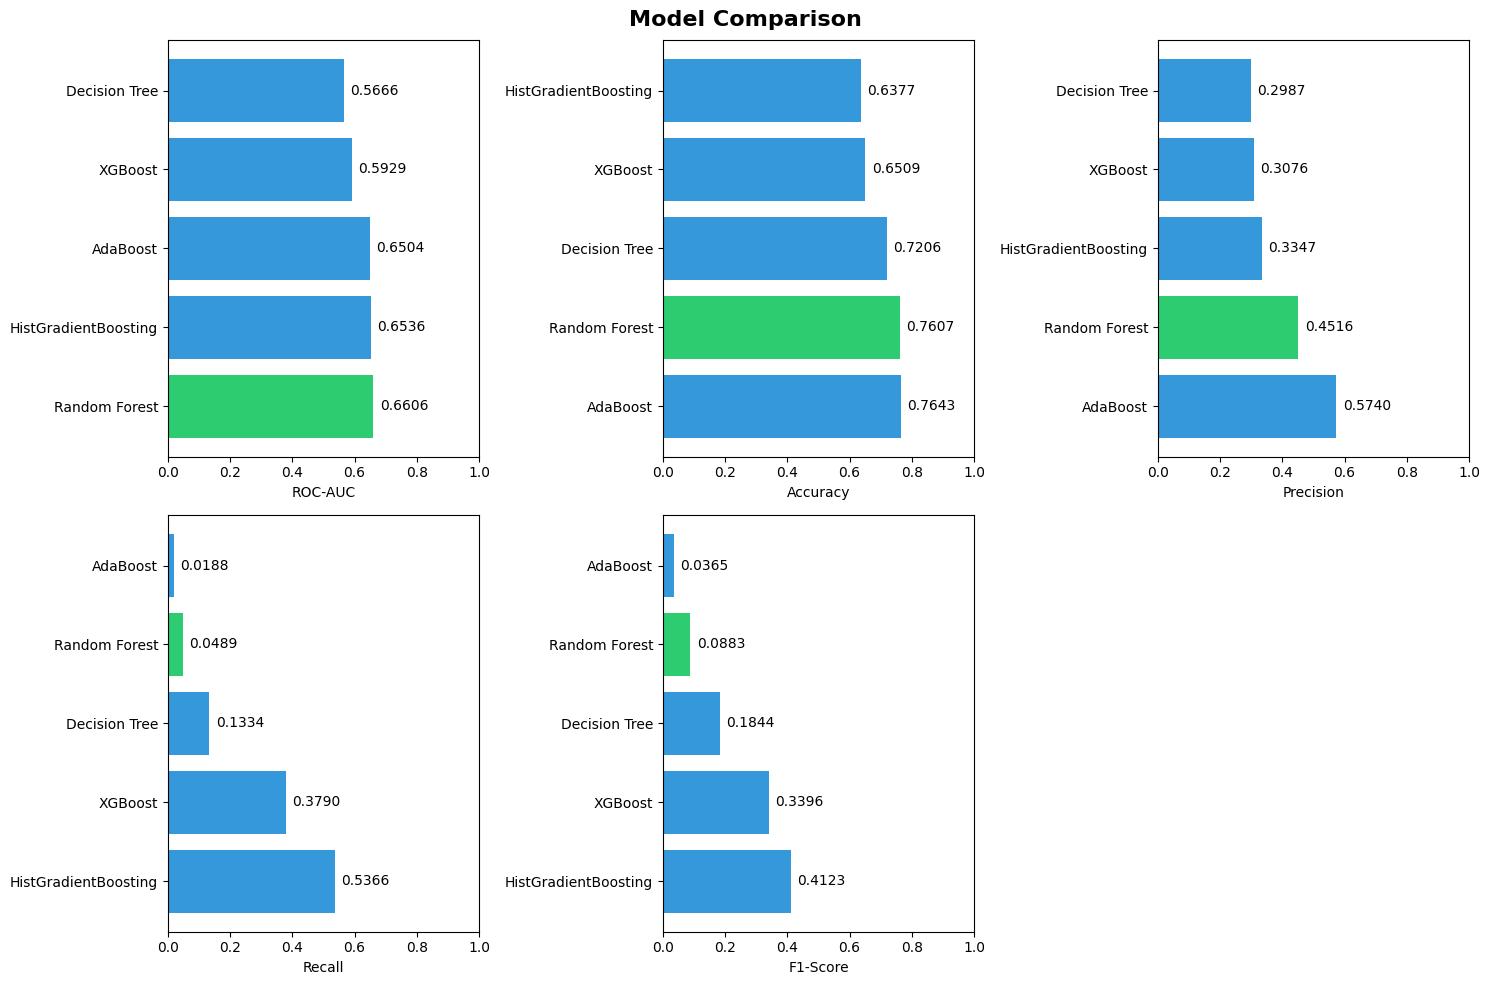

In [ ]:
import matplotlib.pyplot as plt

# Visualize model comparison
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Model Comparison", fontsize=16, fontweight="bold")

metrics = ["ROC-AUC", "Accuracy", "Precision", "Recall", "F1-Score"]
for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    comparison_df_sorted = comparison_df.sort(metric, descending=True)
    colors = [
        "#2ecc71" if model == best_model_name else "#3498db"
        for model in comparison_df_sorted["Model"]
    ]
    ax.barh(comparison_df_sorted["Model"], comparison_df_sorted[metric], color=colors)
    ax.set_xlabel(metric)
    ax.set_xlim([0, 1])
    for i, v in enumerate(comparison_df_sorted[metric]):
        ax.text(v + 0.02, i, f"{v:.4f}", va="center")

# Remove the empty subplot
axes[1, 2].remove()

plt.tight_layout()
plt.show()

# Save the trained models for later use

In [ ]:
import json
from pathlib import Path

if EXPORT:
    models_dir = Path("models")
    models_dir.mkdir(parents=True, exist_ok=True)

    # Save best model metadata with all models' performance
    metadata = {
        "feature_columns": cols,
        "categorical_columns": categorical_cols,
        "categorical_mappings": category_mappings,
        "best_model": best_model_name,
        "best_model_params": search_results[best_model_name],
        "all_models_performance": comparison_df.to_dicts(),  # All model comparisons
        "all_models_best_params": search_results,  # Best params for each model
    }
    with open(models_dir / "metadata.json", "w") as f:
        json.dump(metadata, f, indent=2, default=str)

    print("Metadata saved to models/metadata.json")
    print(f"Best model for export: {best_model_name}")